In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("customer_churn_sample.csv")

df.head()

,CustomerID,Gender,Age,TenureMonths,SubscriptionType,MonthlyCharges,TotalCharges,ContractType,SupportTickets,PaymentMethod,Churn
0,CUST-1001,Female,34,12,Basic,49.99,599.88,Month-to-Month,3,Credit Card,Yes
1,CUST-1002,Male,45,24,Pro,79.99,1919.76,One Year,1,Bank Transfer,No
2,CUST-1003,Female,29,6,Basic,49.99,299.94,Month-to-Month,5,UPI,Yes
3,CUST-1004,Male,52,36,Enterprise,149.99,5399.64,Two Year,0,Credit Card,No
4,CUST-1005,Female,41,8,Pro,79.99,639.92,Month-to-Month,4,Debit Card,Yes


In [5]:
print("Rows and Columns:", df.shape)

df.info()

Rows and Columns: (15, 11)
<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        15 non-null     str    
 1   Gender            15 non-null     str    
 2   Age               15 non-null     int64  
 3   TenureMonths      15 non-null     int64  
 4   SubscriptionType  15 non-null     str    
 5   MonthlyCharges    15 non-null     float64
 6   TotalCharges      15 non-null     float64
 7   ContractType      15 non-null     str    
 8   SupportTickets    15 non-null     int64  
 9   PaymentMethod     15 non-null     str    
 10  Churn             15 non-null     str    
dtypes: float64(2), int64(3), str(6)
memory usage: 1.4 KB


In [6]:
df.describe()

,Age,TenureMonths,MonthlyCharges,TotalCharges,SupportTickets
count,15.000000,15.000000,15.000000,15.000000,15.000000
mean,39.066667,18.800000,84.656667,2088.478667,2.533333
std,11.392144,14.333776,42.739521,2407.365767,1.922300
min,23.000000,2.000000,49.990000,99.980000,0.000000
25%,30.000000,7.000000,49.990000,449.910000,1.000000
50%,38.000000,15.000000,79.990000,1099.780000,2.000000
75%,47.000000,27.000000,114.990000,3209.730000,4.000000
max,60.000000,48.000000,149.990000,7199.520000,6.000000


In [9]:
df.isnull().sum()

CustomerID          0
Gender              0
Age                 0
TenureMonths        0
SubscriptionType    0
MonthlyCharges      0
TotalCharges        0
ContractType        0
SupportTickets      0
PaymentMethod       0
Churn               0
dtype: int64

In [10]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [11]:
df

,CustomerID,Gender,Age,TenureMonths,SubscriptionType,MonthlyCharges,TotalCharges,ContractType,SupportTickets,PaymentMethod,Churn
0,CUST-1001,Female,34,12,Basic,49.99,599.88,Month-to-Month,3,Credit Card,Yes
1,CUST-1002,Male,45,24,Pro,79.99,1919.76,One Year,1,Bank Transfer,No
2,CUST-1003,Female,29,6,Basic,49.99,299.94,Month-to-Month,5,UPI,Yes
3,CUST-1004,Male,52,36,Enterprise,149.99,5399.64,Two Year,0,Credit Card,No
4,CUST-1005,Female,41,8,Pro,79.99,639.92,Month-to-Month,4,Debit Card,Yes
5,CUST-1006,Male,31,18,Basic,49.99,899.82,One Year,2,UPI,No
6,CUST-1007,Female,23,3,Basic,49.99,149.97,Month-to-Month,6,Credit Card,Yes
7,CUST-1008,Male,60,48,Enterprise,149.99,7199.52,Two Year,1,Bank Transfer,No
8,CUST-1009,Female,38,15,Pro,79.99,1199.85,One Year,2,Credit Card,No
9,CUST-1010,Male,27,4,Basic,49.99,199.96,Month-to-Month,4,UPI,Yes


In [12]:
# Check for outliers using IQR

numeric_columns = df.select_dtypes(include=np.number).columns

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower) | (df[column] > upper)]

    print(column, "->", len(outliers), "outlier(s)")

Age -> 0 outlier(s)
TenureMonths -> 0 outlier(s)
MonthlyCharges -> 0 outlier(s)
TotalCharges -> 0 outlier(s)
SupportTickets -> 0 outlier(s)


In [13]:
# Create a copy of the original data
clean_df = df.copy()

# Remove duplicate rows
clean_df = clean_df.drop_duplicates()

print("Original rows:", len(df))
print("Rows after cleaning:", len(clean_df))
print("Duplicates removed:", len(df) - len(clean_df))

Original rows: 15
Rows after cleaning: 15
Duplicates removed: 0


In [14]:
print("Missing values:")
print(clean_df.isnull().sum())

print("\nDuplicate rows:", clean_df.duplicated().sum())

print("\nCleaned dataset shape:", clean_df.shape)

Missing values:
CustomerID          0
Gender              0
Age                 0
TenureMonths        0
SubscriptionType    0
MonthlyCharges      0
TotalCharges        0
ContractType        0
SupportTickets      0
PaymentMethod       0
Churn               0
dtype: int64

Duplicate rows: 0

Cleaned dataset shape: (15, 11)


In [15]:
clean_df.to_csv("clean_customer_churn.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [16]:
# Summary statistics
clean_df.describe()

,Age,TenureMonths,MonthlyCharges,TotalCharges,SupportTickets
count,15.000000,15.000000,15.000000,15.000000,15.000000
mean,39.066667,18.800000,84.656667,2088.478667,2.533333
std,11.392144,14.333776,42.739521,2407.365767,1.922300
min,23.000000,2.000000,49.990000,99.980000,0.000000
25%,30.000000,7.000000,49.990000,449.910000,1.000000
50%,38.000000,15.000000,79.990000,1099.780000,2.000000
75%,47.000000,27.000000,114.990000,3209.730000,4.000000
max,60.000000,48.000000,149.990000,7199.520000,6.000000


In [17]:
# Unique values in categorical columns

categorical_columns = clean_df.select_dtypes(include="object").columns

for column in categorical_columns:
    print("\n", column)
    print(clean_df[column].value_counts())


 CustomerID
CustomerID
CUST-1001    1
CUST-1002    1
CUST-1003    1
CUST-1004    1
CUST-1005    1
CUST-1006    1
CUST-1007    1
CUST-1008    1
CUST-1009    1
CUST-1010    1
CUST-1011    1
CUST-1012    1
CUST-1013    1
CUST-1014    1
CUST-1015    1
Name: count, dtype: int64

 Gender
Gender
Female    8
Male      7
Name: count, dtype: int64

 SubscriptionType
SubscriptionType
Basic         7
Pro           4
Enterprise    4
Name: count, dtype: int64

 ContractType
ContractType
Month-to-Month    7
One Year          4
Two Year          4
Name: count, dtype: int64

 PaymentMethod
PaymentMethod
Credit Card      6
UPI              4
Bank Transfer    3
Debit Card       2
Name: count, dtype: int64

 Churn
Churn
No     8
Yes    7
Name: count, dtype: int64


C:\Users\Shafila Farzana\AppData\Local\Temp\ipykernel_18100\1678959543.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = clean_df.select_dtypes(include="object").columns


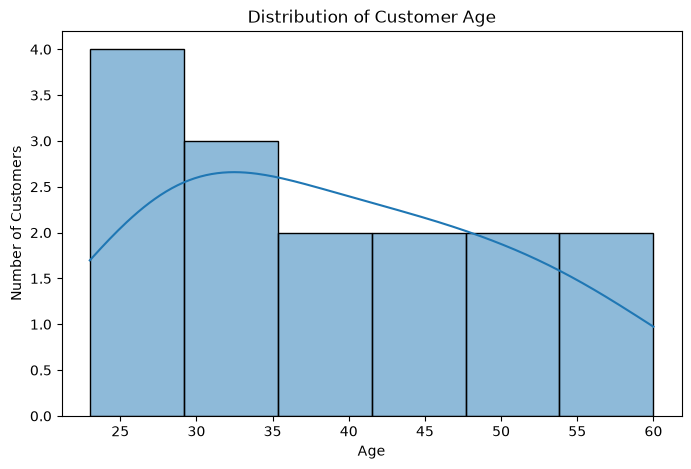

In [18]:
plt.figure(figsize=(8, 5))

sns.histplot(clean_df["Age"], bins=6, kde=True)

plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

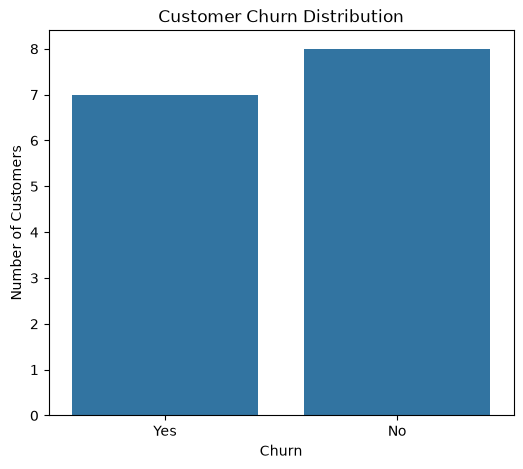

In [19]:
plt.figure(figsize=(6, 5))

sns.countplot(data=clean_df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [22]:
print("FINAL VALIDATION")
print("----------------")
print("Rows:", clean_df.shape[0])
print("Columns:", clean_df.shape[1])
print("Missing values:", clean_df.isnull().sum().sum())
print("Duplicate rows:", clean_df.duplicated().sum())

FINAL VALIDATION
----------------
Rows: 15
Columns: 11
Missing values: 0
Duplicate rows: 0


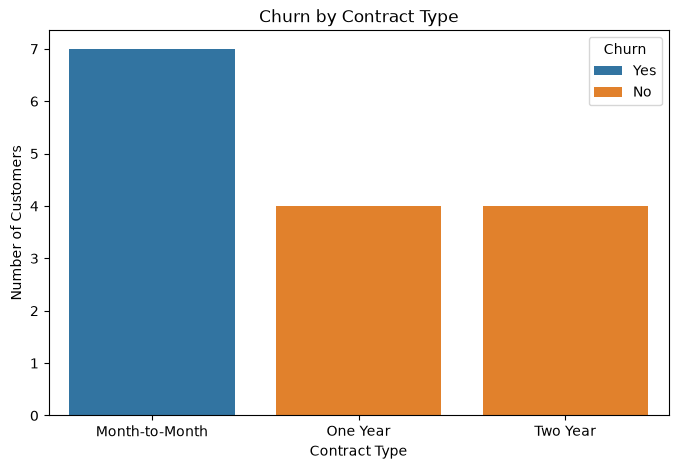

In [20]:
plt.figure(figsize=(8, 5))

sns.countplot(data=clean_df, x="ContractType", hue="Churn")

plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()